In [1]:
# imports
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import random

from sklearn import cluster, metrics

from scipy.stats import mannwhitneyu, false_discovery_control, ttest_ind, kstest
from matplotlib.patches import Patch

import cooler 
import cooltools
from matplotlib.colors import LogNorm
import cooltools.lib.plotting
from matplotlib.backends.backend_pdf import PdfPages

from functools import reduce 

import re
#from collections import Counter
import ast 

%cd /home/varshini/uc_analyses/
import utils, matchmaker_functions, loops_txn
%cd /home/varshini/LoopCall_Analysis_Scripts


# plot formatting
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams.update({'font.size': 12})

plt.rcParams["legend.frameon"] = False

/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


/home/varshini/microc_analyses/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
## functions 

def search_dist_for_proms(peaks_df, proms_df, dist):
    peaks_df = peaks_df.copy()
    proms_df = proms_df.copy()
    peaks_df['genes'] = [[] for _ in range(len(peaks_df))]
    peaks_df['l2fc'] = [[] for _ in range(len(peaks_df))]
    for peak_idx, peak_row in peaks_df.iterrows():
        
        peak_chr = peak_row['chr'].split('chr')[1]
        peak_coord = peak_row['coord']
        proms_df['dist'] = abs(proms_df['transcription_start_site'] - peak_coord)
        # Find genes whose TSS is within X of the peak
        nearby_genes = proms_df[
            (proms_df['chromosome_name'] == peak_chr) &
            (abs(proms_df['transcription_start_site'] - peak_coord) <= dist)
        ]

        peaks_df.at[peak_idx, 'genes'] = nearby_genes['external_gene_name'].tolist()
        peaks_df.at[peak_idx, 'min_dist'] = nearby_genes['dist'].min()
        
        if 'log2FoldChange' in proms_df.columns:
            peaks_df.at[peak_idx, 'l2fc'] = nearby_genes['log2FoldChange'].mean()
            
    peaks_df['num_genes'] = peaks_df['genes'].apply(len)
    
    return peaks_df

    
def assign_proms_to_mm(peaks_df, proms_df, min_dist, max_dist):
    peaks = peaks_df.copy()
    proms = proms_df.copy()
    
    # normalize chromosome naming
    peaks["chromosome_name"] = peaks["chr"].str.replace("chr", "", regex=False)

    # output columns
    proms["mm_quant"] = np.nan
    proms["dist"] = np.nan
    proms["triangle_fc"] = np.nan
    proms["mm_peak"] = np.nan

    for chrom, proms_sub in proms.groupby("chromosome_name"):
        peaks_sub = peaks[peaks["chromosome_name"] == chrom]
        if peaks_sub.empty:
            continue

        # sort peaks once
        peaks_sub = peaks_sub.sort_values("coord")
        peak_coords = peaks_sub["coord"].values
        peak_quants = peaks_sub["quant_diff"].values
        tri_scores = peaks_sub["crosser_fc"].values
        # promoter coords
        prom_coords = proms_sub["transcription_start_site"].values

        # find insertion positions
        idxs = np.searchsorted(peak_coords, prom_coords)

        # clip to valid range
        idxs_left = np.clip(idxs - 1, 0, len(peak_coords) - 1)
        idxs_right = np.clip(idxs, 0, len(peak_coords) - 1)

        # compute distances to neighbors
        d_left = np.abs(prom_coords - peak_coords[idxs_left])
        d_right = np.abs(prom_coords - peak_coords[idxs_right])

        # choose nearest
        use_left = d_left <= d_right
        nearest_idxs = np.where(use_left, idxs_left, idxs_right)
        d = np.minimum(d_left, d_right)

        valid = (d <= max_dist) & (d >= min_dist)

        proms.loc[proms_sub.index[valid], "mm_quant"] = peak_quants[nearest_idxs[valid]]
        proms.loc[proms_sub.index[valid], "dist"] = d[valid]
        proms.loc[proms_sub.index[valid], "triangle_fc"] = tri_scores[nearest_idxs[valid]]
        proms.loc[proms_sub.index[valid], "mm_peak"] = peak_coords[nearest_idxs[valid]]

    return proms

In [3]:
dist = 100000

In [4]:
# load nfe2 mms (already grouped) and gex
basedir = "/mnt/md0/varshini/Analysis/Blood/complete_analyses"

#nfe2_only_tf_{dist//1000}kb_merge{diff_thresh/1000}kb_clus.bed
mm_df = pd.read_csv(os.path.join(basedir, "matchmakers", "nfe2_only_tf_100kb_merge10.0kb_clus.bed"),
                   sep="\t")
mm_df = matchmaker_functions.merged_attrs(mm_df,'P2', 'P1')
quant_range = np.sort(mm_df['quant'].unique() + 1)

tpms = pd.read_csv(os.path.join(basedir,"gene_sets_expr","rnaseq_tpm_annotated_nfe2.tsv"), sep="\t")
up = pd.read_csv(os.path.join(basedir,"gene_sets_expr","NFE2_P3_AAVS1_P3_up_lfcShrink_sepExp2.txt"), sep="\t")
down = pd.read_csv(os.path.join(basedir,"gene_sets_expr","NFE2_P3_AAVS1_P3_down_lfcShrink_sepExp2.txt"), sep="\t")

down = down[down['log2FoldChange']<-0.5]
up = up[up['log2FoldChange']>0.5]

In [5]:
tpms

,ensembl_id,IKZF1_P3_D1,IKZF1_P2_D1,DMSO_P3_D1,AAVS1_P3_D1,IKZF1_P3_D2,STAG2_C3_G2,AAVS1_P3_D2,STAG1_C3_G1,DMSO_P3_D2,NFE2_P3_D2,NFE2_P3_D1,external_gene_name,refseq_mrna,gene_biotype,chromosome_name,transcript_start,transcript_end,transcript_length,strand
0,ENSG00000000003,0.781652,1.290607,0.396594,0.216087,0.661938,0.949627,0.289442,0.554559,0.592631,1.231743,1.606465,TSPAN6,NM_003270,protein_coding,X,100627108,100636806,3768,-1
1,ENSG00000000005,0.000000,0.403569,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.226566,0.000000,TNMD,NM_022144,protein_coding,X,100584936,100599885,1205,1
2,ENSG00000000419,69.160670,114.654370,69.826834,91.927739,92.158005,96.187979,70.103739,99.291385,88.187901,105.941191,101.127403,DPM1,NM_003859,protein_coding,20,50934870,50958532,1054,-1
3,ENSG00000000457,2.392912,2.235688,2.724350,4.453153,2.789765,1.922336,3.717229,1.987552,2.389502,3.397505,3.045689,SCYL3,NM_020423,protein_coding,1,169849631,169893896,6308,-1
4,ENSG00000000460,9.821227,13.579075,8.382751,10.251300,12.471256,15.165614,9.244826,17.886372,11.134551,13.102683,15.091403,FIRRM,NM_001320047,protein_coding,1,169795040,169854080,4011,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61916,ENSG00000293556,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,lncRNA,7,149776435,149783291,556,1
61917,ENSG00000293557,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,lncRNA,7,149822144,149827891,419,1
61918,ENSG00000293558,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,lncRNA,7,149810915,149812635,394,1
61919,ENSG00000293559,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,unitary_pseudogene,7,99238829,99271093,2366,1


In [6]:
tpms = tpms.set_index('ensembl_id')

In [7]:
# process atac in one shot
atac_proms = pd.read_csv("/mnt/md0/varshini/Analysis/Blood/complete_analyses/gene_sets_expr/promoters_accessible_all.bed",
                        sep="\t",
                        names=['chr','start','end','accession','alt','strand']).drop('alt',axis=1).drop_duplicates()

lut = pd.read_csv("/mnt/md0/varshini/Analysis/Adipose/GeneExp/tss_hg38_all_types.tsv",
                 sep="\t").drop_duplicates(subset=['external_gene_name','refseq_id'])

atac_proms_dedup = utils.clean_chroms(atac_proms.merge(lut, how='left', left_on='accession', right_on='refseq_id'))
atac_proms_dedup.drop_duplicates(subset='external_gene_name', inplace=True)
atac_proms_dedup.sort_values(by=['chr','start','end'], inplace=True)

atac_to_mms = assign_proms_to_mm(mm_df, atac_proms_dedup, 0, dist)

/tmp/ipykernel_12351/2053403066.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  lut = pd.read_csv("/mnt/md0/varshini/Analysis/Adipose/GeneExp/tss_hg38_all_types.tsv",


In [8]:
def find_tss(row):
    if row.strand == -1:
        return row.transcript_end
    elif row.strand == 1:
        return row.transcript_start
    else:
        raise ValueError("Invalid Strand")
    

In [9]:
tpms.columns

Index(['IKZF1_P3_D1', 'IKZF1_P2_D1', 'DMSO_P3_D1', 'AAVS1_P3_D1',
       'IKZF1_P3_D2', 'STAG2_C3_G2', 'AAVS1_P3_D2', 'STAG1_C3_G1',
       'DMSO_P3_D2', 'NFE2_P3_D2', 'NFE2_P3_D1', 'external_gene_name',
       'refseq_mrna', 'gene_biotype', 'chromosome_name', 'transcript_start',
       'transcript_end', 'transcript_length', 'strand'],
      dtype='object')

In [10]:
tpms.drop(['IKZF1_P3_D1', 'IKZF1_P2_D1', 'DMSO_P3_D1',
           'IKZF1_P3_D2', 'STAG2_C3_G2','STAG1_C3_G1',
       'DMSO_P3_D2',], axis=1, inplace=True)

In [17]:
tpms['transcription_start_site'] = tpms.apply(find_tss, axis=1)
tpms = tpms.drop_duplicates(subset='external_gene_name')

tpms['AAVS1_avg'] = tpms[['AAVS1_P3_D1', 'AAVS1_P3_D2']].mean(axis=1)
tpms['NFE2_avg'] = tpms[['NFE2_P3_D1', 'NFE2_P3_D2']].mean(axis=1)
tpms['FC_avg'] = np.log2(tpms['NFE2_avg'].divide(tpms['AAVS1_avg']))
tpms['FC_D1'] = np.log2(tpms['NFE2_P3_D1'].divide(tpms['AAVS1_P3_D1']))
tpms['FC_D2'] = np.log2(tpms['NFE2_P3_D2'].divide(tpms['AAVS1_P3_D2']))
tpms_expr = tpms[~tpms['FC_avg'].isna()]

/home/varshini/microc_analyses/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/varshini/microc_analyses/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/varshini/microc_analyses/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [18]:
down_tpms = down.merge(tpms, how='left', left_index = True, right_index=True)
up_tpms = up.merge(tpms, how='left', left_index = True, right_index=True)

In [19]:
down_tpms

,baseMean,log2FoldChange,lfcSE,pvalue,padj,AAVS1_P3_D1,AAVS1_P3_D2,NFE2_P3_D2,NFE2_P3_D1,external_gene_name,...,transcript_start,transcript_end,transcript_length,strand,transcription_start_site,AAVS1_avg,NFE2_avg,FC_avg,FC_D1,FC_D2
ENSG00000289740,1031.901689,-2.957374,0.259066,1.516510e-32,3.255645e-29,67.074872,14.009781,2.994412,7.812596,TALAM1,...,65499045.0,65507432.0,8388.0,-1.0,65507432.0,40.542327,5.403504,-2.907462,-3.101898,-2.226090
ENSG00000035403,684.243547,-2.526510,0.250308,2.648117e-26,3.553111e-23,26.167363,27.069237,4.878192,6.435880,VCL,...,73998114.0,74123073.0,8199.0,1.0,73998114.0,26.618300,5.657036,-2.234300,-2.023559,-2.472236
ENSG00000206172,10636.263645,-1.607982,0.168824,9.749246e-23,1.046484e-19,5678.352987,4657.806538,1820.476044,2475.360470,HBA1,...,176680.0,177522.0,577.0,1.0,176680.0,5168.079763,2147.918257,-1.266689,-1.197834,-1.355335
ENSG00000138166,662.278917,-2.851409,0.310728,1.738535e-22,1.696494e-19,100.256851,71.658462,7.219339,25.499970,DUSP5,...,110497907.0,110511533.0,2477.0,1.0,110497907.0,85.957657,16.359655,-2.393484,-1.975133,-3.311198
ENSG00000181220,876.294555,-2.034512,0.227061,4.080475e-21,3.649985e-18,60.681827,74.879053,20.381850,19.882991,ZNF746,...,149472696.0,149497831.0,3918.0,-1.0,149497831.0,67.780440,20.132420,-1.751348,-1.609730,-1.877277
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000105643,3582.533811,-0.763648,0.580636,3.418145e-03,4.632622e-02,316.115482,477.281464,146.931029,209.934421,ARRDC2,...,18008170.0,18014102.0,2501.0,1.0,18008170.0,396.698473,178.432725,-1.152663,-0.590513,-1.699701
ENSG00000052841,536.047631,-0.502992,0.281821,3.512029e-03,4.709461e-02,27.031718,28.492627,18.371146,24.717194,TTC17,...,43358920.0,43494931.0,4488.0,1.0,43358920.0,27.762173,21.544170,-0.365823,-0.129138,-0.633147
ENSG00000139266,134.925709,-0.681170,0.470379,3.511685e-03,4.709461e-02,10.106016,13.536682,6.731433,6.400744,MARCHF9,...,57755103.0,57760411.0,2981.0,1.0,57755103.0,11.821349,6.566089,-0.848289,-0.658903,-1.007889
ENSG00000198380,321.286058,-0.549181,0.328202,3.555581e-03,4.752878e-02,9.556323,7.846391,6.192920,6.133265,GFPT1,...,69319616.0,69387313.0,8861.0,-1.0,69387313.0,8.701357,6.163093,-0.497586,-0.639800,-0.341409


In [20]:
genes_to_mms = assign_proms_to_mm(mm_df, down_tpms, 0, dist)
genes_to_mms_comp = assign_proms_to_mm(mm_df, up_tpms, 0, dist)

In [21]:
genes_to_mms

,baseMean,log2FoldChange,lfcSE,pvalue,padj,AAVS1_P3_D1,AAVS1_P3_D2,NFE2_P3_D2,NFE2_P3_D1,external_gene_name,...,transcription_start_site,AAVS1_avg,NFE2_avg,FC_avg,FC_D1,FC_D2,mm_quant,dist,triangle_fc,mm_peak
ENSG00000289740,1031.901689,-2.957374,0.259066,1.516510e-32,3.255645e-29,67.074872,14.009781,2.994412,7.812596,TALAM1,...,65507432.0,40.542327,5.403504,-2.907462,-3.101898,-2.226090,NaN,NaN,NaN,NaN
ENSG00000035403,684.243547,-2.526510,0.250308,2.648117e-26,3.553111e-23,26.167363,27.069237,4.878192,6.435880,VCL,...,73998114.0,26.618300,5.657036,-2.234300,-2.023559,-2.472236,3.0,13549.0,0.853957,74011663.0
ENSG00000206172,10636.263645,-1.607982,0.168824,9.749246e-23,1.046484e-19,5678.352987,4657.806538,1820.476044,2475.360470,HBA1,...,176680.0,5168.079763,2147.918257,-1.266689,-1.197834,-1.355335,NaN,NaN,NaN,NaN
ENSG00000138166,662.278917,-2.851409,0.310728,1.738535e-22,1.696494e-19,100.256851,71.658462,7.219339,25.499970,DUSP5,...,110497907.0,85.957657,16.359655,-2.393484,-1.975133,-3.311198,NaN,NaN,NaN,NaN
ENSG00000181220,876.294555,-2.034512,0.227061,4.080475e-21,3.649985e-18,60.681827,74.879053,20.381850,19.882991,ZNF746,...,149497831.0,67.780440,20.132420,-1.751348,-1.609730,-1.877277,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000105643,3582.533811,-0.763648,0.580636,3.418145e-03,4.632622e-02,316.115482,477.281464,146.931029,209.934421,ARRDC2,...,18008170.0,396.698473,178.432725,-1.152663,-0.590513,-1.699701,NaN,NaN,NaN,NaN
ENSG00000052841,536.047631,-0.502992,0.281821,3.512029e-03,4.709461e-02,27.031718,28.492627,18.371146,24.717194,TTC17,...,43358920.0,27.762173,21.544170,-0.365823,-0.129138,-0.633147,NaN,NaN,NaN,NaN
ENSG00000139266,134.925709,-0.681170,0.470379,3.511685e-03,4.709461e-02,10.106016,13.536682,6.731433,6.400744,MARCHF9,...,57755103.0,11.821349,6.566089,-0.848289,-0.658903,-1.007889,NaN,NaN,NaN,NaN
ENSG00000198380,321.286058,-0.549181,0.328202,3.555581e-03,4.752878e-02,9.556323,7.846391,6.192920,6.133265,GFPT1,...,69387313.0,8.701357,6.163093,-0.497586,-0.639800,-0.341409,1.0,5833.5,NaN,69381479.5


In [22]:
genes_to_mms.groupby('mm_quant').agg('size')

mm_quant
0.0    25
1.0    28
2.0    26
3.0     9
dtype: int64

In [23]:
atac_to_mms.groupby('mm_quant').agg('size')

mm_quant
0.0    394
1.0    576
2.0    395
3.0    163
dtype: int64

In [24]:
genes_to_mms

,baseMean,log2FoldChange,lfcSE,pvalue,padj,AAVS1_P3_D1,AAVS1_P3_D2,NFE2_P3_D2,NFE2_P3_D1,external_gene_name,...,transcription_start_site,AAVS1_avg,NFE2_avg,FC_avg,FC_D1,FC_D2,mm_quant,dist,triangle_fc,mm_peak
ENSG00000289740,1031.901689,-2.957374,0.259066,1.516510e-32,3.255645e-29,67.074872,14.009781,2.994412,7.812596,TALAM1,...,65507432.0,40.542327,5.403504,-2.907462,-3.101898,-2.226090,NaN,NaN,NaN,NaN
ENSG00000035403,684.243547,-2.526510,0.250308,2.648117e-26,3.553111e-23,26.167363,27.069237,4.878192,6.435880,VCL,...,73998114.0,26.618300,5.657036,-2.234300,-2.023559,-2.472236,3.0,13549.0,0.853957,74011663.0
ENSG00000206172,10636.263645,-1.607982,0.168824,9.749246e-23,1.046484e-19,5678.352987,4657.806538,1820.476044,2475.360470,HBA1,...,176680.0,5168.079763,2147.918257,-1.266689,-1.197834,-1.355335,NaN,NaN,NaN,NaN
ENSG00000138166,662.278917,-2.851409,0.310728,1.738535e-22,1.696494e-19,100.256851,71.658462,7.219339,25.499970,DUSP5,...,110497907.0,85.957657,16.359655,-2.393484,-1.975133,-3.311198,NaN,NaN,NaN,NaN
ENSG00000181220,876.294555,-2.034512,0.227061,4.080475e-21,3.649985e-18,60.681827,74.879053,20.381850,19.882991,ZNF746,...,149497831.0,67.780440,20.132420,-1.751348,-1.609730,-1.877277,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000105643,3582.533811,-0.763648,0.580636,3.418145e-03,4.632622e-02,316.115482,477.281464,146.931029,209.934421,ARRDC2,...,18008170.0,396.698473,178.432725,-1.152663,-0.590513,-1.699701,NaN,NaN,NaN,NaN
ENSG00000052841,536.047631,-0.502992,0.281821,3.512029e-03,4.709461e-02,27.031718,28.492627,18.371146,24.717194,TTC17,...,43358920.0,27.762173,21.544170,-0.365823,-0.129138,-0.633147,NaN,NaN,NaN,NaN
ENSG00000139266,134.925709,-0.681170,0.470379,3.511685e-03,4.709461e-02,10.106016,13.536682,6.731433,6.400744,MARCHF9,...,57755103.0,11.821349,6.566089,-0.848289,-0.658903,-1.007889,NaN,NaN,NaN,NaN
ENSG00000198380,321.286058,-0.549181,0.328202,3.555581e-03,4.752878e-02,9.556323,7.846391,6.192920,6.133265,GFPT1,...,69387313.0,8.701357,6.163093,-0.497586,-0.639800,-0.341409,1.0,5833.5,NaN,69381479.5


In [25]:
def get_odds(test_set, comp_set, background_set, quant_range, test_title='P3 Marker Genes', comp_title='Background'): # first three are output from the mm finder function
    results = []
    
    for quant in quant_range:
        genes_to_mms_test = test_set[(test_set['mm_quant'].isin(quant))]
        genes_to_mms_comp = comp_set[(comp_set['mm_quant'].isin(quant))]
        
        if ("external_gene_name" not in test_set.columns) or ("external_gene_name" not in background_set.columns) or ("external_gene_name" not in comp_set.columns):
            print("Warning")
        
        # get the background which is not in the test set or comparison set
        bg_not_test = pd.merge(background_set, genes_to_mms_test,
                              left_on="ensembl_gene_id",  right_index=True, how="outer", indicator=True, suffixes=('', '_explode'))
        bg_not_test = bg_not_test[bg_not_test['_merge']=='left_only']
        bg_not_test =  bg_not_test[(bg_not_test['mm_quant'].isin(quant))]
        
        
        bg_not_comp = pd.merge(background_set, genes_to_mms_comp,
                               left_on="ensembl_gene_id",  right_index=True,  how="outer",indicator=True, suffixes=('', '_explode'))
        bg_not_comp = bg_not_comp[bg_not_comp['_merge']=='left_only']
        bg_not_comp =  bg_not_comp[(bg_not_comp['mm_quant'].isin(quant))]
        

        tbl_test = [[len(genes_to_mms_test), len(bg_not_test)],
           [len(test_set) - len(genes_to_mms_test), len(background_set) - len(bg_not_test)]]

        tbl_control = [[len(genes_to_mms_comp), len(bg_not_comp)],
           [len(comp_set) - len(genes_to_mms_comp), len(background_set) - len(bg_not_comp)]]

        print(tbl_test)
        print(tbl_control)
        print(fisher_exact(tbl_test))
        print(odds_ratio(tbl_test).confidence_interval(confidence_level=0.95))
        print(scipy.stats.contingency.odds_ratio(tbl_test))
        print("\n")
        print(fisher_exact(tbl_control))
        print(odds_ratio(tbl_control).confidence_interval(confidence_level=0.95))
        print(scipy.stats.contingency.odds_ratio(tbl_control))
        print("\n")
        
        for group, tbl in [(test_title, tbl_test), (comp_title, tbl_control)]:
            or_res = odds_ratio(tbl)
            ci = or_res.confidence_interval(confidence_level=0.95)

            results.append({
                'quant': quant,
                'group': group,
                'OR': or_res.statistic,
                'CI_low': ci.low,
                'CI_high': ci.high
            })
            
    return results

def plot_odds(results, num_quant, test_title, comp_title, bg_str):

    fig, ax = plt.subplots(figsize=(6, 4))
    results = pd.DataFrame(results)
    width = 0.35

    x = np.arange(num_quant)
    colors = {test_title:"#0077BB",  comp_title:"#EE3377"}
    for offset, group in zip([-width/2, width/2], [test_title, comp_title]):

        curr = results[results['group'] == group].sort_values('quant')

        y = curr['OR'].values

        yerr = np.vstack([
            y - curr['CI_low'].values,
            curr['CI_high'].values - y
        ])

        ax.bar(
            x + offset,
            y,
            width=width,
            yerr=yerr,
            capsize=4,
            label=group,
            color=colors[group]

        )

    ax.axhline(1, ls='--', c='k')
    ax.set_xticks(x)
    ax.set_xticklabels(range(num_quant))
    ax.set_xlabel("Matchmaker Cluster (Low to High)")
    ax.set_ylabel(f"Odds Ratio over {bg_str}")
    ax.legend()
    
    return fig


In [26]:
import scipy
from scipy.stats import fisher_exact
from scipy.stats.contingency import odds_ratio

In [22]:
savedir="/mnt/md0/varshini/Analysis/Blood/figs_v4/supp13"

if not os.path.exists(savedir):
    os.mkdir(savedir)

[[25, 373], [543, 19656]]
[[8, 387], [144, 19642]]
SignificanceResult(statistic=2.426199398634337, pvalue=0.00013851418568770516)
ConfidenceInterval(low=1.5360040351598876, high=3.677275385274293)
OddsRatioResult(statistic=2.4260414221494426)


SignificanceResult(statistic=2.819695664656905, pvalue=0.010259637997465019)
ConfidenceInterval(low=1.185932478608003, high=5.761530059210261)
OddsRatioResult(statistic=2.819453034724143)


[[28, 556], [540, 19473]]
[[10, 570], [142, 19459]]
SignificanceResult(statistic=1.816027178257394, pvalue=0.004476655084909623)
ConfidenceInterval(low=1.1842149380282996, high=2.6842076077807735)
OddsRatioResult(statistic=1.815958223936169)


SignificanceResult(statistic=2.4041265134667653, pvalue=0.012579337748566207)
ConfidenceInterval(low=1.1222554547776222, high=4.584586133330787)
OddsRatioResult(statistic=2.4039671384737953)


[[26, 377], [542, 19652]]
[[5, 392], [147, 19637]]
SignificanceResult(statistic=2.5005725919328157, pvalue=7.102594975214044e-05

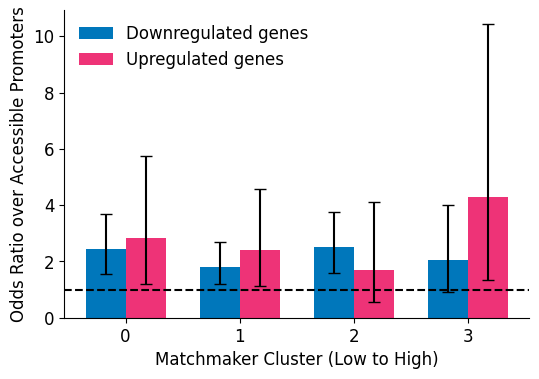

In [28]:
test_title = 'Downregulated genes'
comp_title = 'Upregulated genes'

results = get_odds(genes_to_mms, genes_to_mms_comp, atac_to_mms, ([0],[1],[2], [3]), 
                   test_title=test_title, comp_title=comp_title)

fig = plot_odds(results, 4, test_title, comp_title, 'Accessible Promoters')
plt.show()
#fig.savefig(os.path.join(savedir, "nfe2_degs_or.svg"))

<BarContainer object of 4 artists>

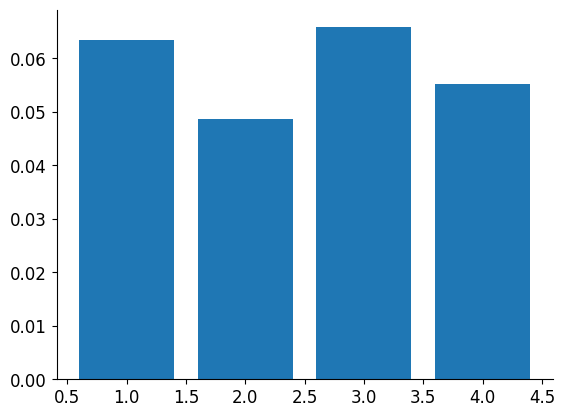

In [29]:
plt.bar(quant_range, genes_to_mms.dropna(subset='dist').groupby('mm_quant').agg('size')/atac_to_mms.dropna(subset='dist').groupby('mm_quant').agg('size'))


In [12]:
tpms

,ensembl_id,IKZF1_P3_D1,IKZF1_P2_D1,DMSO_P3_D1,AAVS1_P3_D1,IKZF1_P3_D2,STAG2_C3_G2,AAVS1_P3_D2,STAG1_C3_G1,DMSO_P3_D2,...,NFE2_P3_D1,external_gene_name,refseq_mrna,gene_biotype,chromosome_name,transcript_start,transcript_end,transcript_length,strand,transcription_start_site
0,ENSG00000000003,0.781652,1.290607,0.396594,0.216087,0.661938,0.949627,0.289442,0.554559,0.592631,...,1.606465,TSPAN6,NM_003270,protein_coding,X,100627108,100636806,3768,-1,100636806
1,ENSG00000000005,0.000000,0.403569,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,TNMD,NM_022144,protein_coding,X,100584936,100599885,1205,1,100584936
2,ENSG00000000419,69.160670,114.654370,69.826834,91.927739,92.158005,96.187979,70.103739,99.291385,88.187901,...,101.127403,DPM1,NM_003859,protein_coding,20,50934870,50958532,1054,-1,50958532
3,ENSG00000000457,2.392912,2.235688,2.724350,4.453153,2.789765,1.922336,3.717229,1.987552,2.389502,...,3.045689,SCYL3,NM_020423,protein_coding,1,169849631,169893896,6308,-1,169893896
4,ENSG00000000460,9.821227,13.579075,8.382751,10.251300,12.471256,15.165614,9.244826,17.886372,11.134551,...,15.091403,FIRRM,NM_001320047,protein_coding,1,169795040,169854080,4011,1,169795040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61709,ENSG00000293312,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,HNRNPKP3,NaN,lncRNA,11,43120762,43269393,589,-1,43269393
61722,ENSG00000293326,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,LINC00359,NaN,lncRNA,13,96940149,96948346,2004,-1,96948346
61864,ENSG00000293488,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,CLECL1,NM_001441804,protein_coding,12,9715017,9733299,2415,-1,9733299
61908,ENSG00000293543,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,DUSP13A,NM_001007271,protein_coding,10,75105669,75109157,567,-1,75109157


In [11]:
min_exp = 1
tpms = pd.read_csv(os.path.join(basedir,"gene_sets_expr","rnaseq_tpm_annotated_nfe2.tsv"), sep="\t")
# tpms.drop(['IKZF1_P3_D1', 'IKZF1_P2_D1', 'DMSO_P2_D2', 'DMSO_P3_D1',
#            'AAVS1_C2_G1', 'IKZF1_P3_D2', 'STAG2_C3_G2',
#        'STAG2_C2_G2','IKZF1_P2_D2', 'NIPBL_C3_G1',
#        'STAG1_C3_G1', 'DMSO_P3_D2','NIPBL_C2_G1','STAG1_C2_G1','DMSO_P2_D1'], axis=1, inplace=True)

tpms['transcription_start_site'] = tpms.apply(find_tss, axis=1)
tpms = tpms.drop_duplicates(subset='external_gene_name')
tpms = tpms.set_index('ensembl_id')
tpms['AAVS1_avg'] = tpms[['AAVS1_P3_D1', 'AAVS1_P3_D2']].mean(axis=1)
tpms['NFE2_avg'] = tpms[['NFE2_P3_D1', 'NFE2_P3_D2']].mean(axis=1)
tpms['FC_avg'] = np.log2(tpms['NFE2_avg'].divide(tpms['AAVS1_avg']))
tpms['FC_D1'] = np.log2(tpms['NFE2_P3_D1'].divide(tpms['AAVS1_P3_D1']))
tpms['FC_D2'] = np.log2(tpms['NFE2_P3_D2'].divide(tpms['AAVS1_P3_D2']))
tpms['FC_avg'] = np.log2(tpms['NFE2_avg'].divide(tpms['AAVS1_avg']))
tpms['FC_D1'] = np.log2(tpms['NFE2_P3_D1'].divide(tpms['AAVS1_P3_D1']))
tpms['FC_D2'] = np.log2(tpms['NFE2_P3_D2'].divide(tpms['AAVS1_P3_D2']))
tpms['log2FoldChange'] = tpms['FC_avg']
tpms_expr = tpms[~tpms.replace([np.inf, -np.inf], np.nan)['FC_avg'].isna()]
tpms_expr = tpms_expr[(tpms_expr['NFE2_avg']>min_exp)|(tpms_expr['AAVS1_avg']>min_exp)]


/home/varshini/microc_analyses/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/varshini/microc_analyses/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/varshini/microc_analyses/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/varshini/microc_analyses/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [12]:
mm_df_change = mm_df.copy()
mm_df_change = mm_df_change[mm_df_change['quant_diff']>1] # legit MMs only

mm_df_change['quant'] = pd.qcut(mm_df_change['crosser_fc'], 2, labels=False)

In [13]:
mm_df_change.groupby('quant').agg('crosser_fc').min()

quant
0.0    0.412270
1.0    0.968023
Name: crosser_fc, dtype: float64

In [14]:
tpms_expr

,IKZF1_P3_D1,IKZF1_P2_D1,DMSO_P3_D1,AAVS1_P3_D1,IKZF1_P3_D2,STAG2_C3_G2,AAVS1_P3_D2,STAG1_C3_G1,DMSO_P3_D2,NFE2_P3_D2,...,transcript_end,transcript_length,strand,transcription_start_site,AAVS1_avg,NFE2_avg,FC_avg,FC_D1,FC_D2,log2FoldChange
ensembl_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,0.781652,1.290607,0.396594,0.216087,0.661938,0.949627,0.289442,0.554559,0.592631,1.231743,...,100636806,3768,-1,100636806,0.252765,1.419104,2.489114,2.894203,2.089355,2.489114
ENSG00000000419,69.160670,114.654370,69.826834,91.927739,92.158005,96.187979,70.103739,99.291385,88.187901,105.941191,...,50958532,1054,-1,50958532,81.015739,103.534297,0.353835,0.137602,0.595700,0.353835
ENSG00000000457,2.392912,2.235688,2.724350,4.453153,2.789765,1.922336,3.717229,1.987552,2.389502,3.397505,...,169893896,6308,-1,169893896,4.085191,3.221597,-0.342627,-0.548058,-0.129752,-0.342627
ENSG00000000460,9.821227,13.579075,8.382751,10.251300,12.471256,15.165614,9.244826,17.886372,11.134551,13.102683,...,169854080,4011,1,169795040,9.748063,14.097043,0.532205,0.557920,0.503144,0.532205
ENSG00000000938,1.116900,1.751936,2.550111,4.013964,4.413924,0.301537,2.481496,0.264136,2.963830,1.035314,...,27635185,2637,-1,27635185,3.247730,1.041624,-1.640598,-1.937481,-1.261142,-1.640598
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000289740,4.959691,2.956763,5.790041,67.074872,7.879808,4.645034,14.009781,2.802548,6.622166,2.994412,...,65507432,8388,-1,65507432,40.542327,5.403504,-2.907462,-3.101898,-2.226090,-2.907462
ENSG00000290292,8.934448,7.022392,7.417877,5.552223,9.004268,8.412429,9.132227,5.378314,6.214069,12.237914,...,23286132,4986,-1,23286132,7.342225,9.840228,0.422474,0.422730,0.422319,0.422474
ENSG00000291237,17.801119,16.888537,18.538482,24.282257,22.955717,20.444330,18.225716,19.322012,18.894965,21.535343,...,159693241,14167,-1,159693241,21.253986,22.917057,0.108688,0.000981,0.240731,0.108688


In [15]:
tpms_expr

,IKZF1_P3_D1,IKZF1_P2_D1,DMSO_P3_D1,AAVS1_P3_D1,IKZF1_P3_D2,STAG2_C3_G2,AAVS1_P3_D2,STAG1_C3_G1,DMSO_P3_D2,NFE2_P3_D2,...,transcript_end,transcript_length,strand,transcription_start_site,AAVS1_avg,NFE2_avg,FC_avg,FC_D1,FC_D2,log2FoldChange
ensembl_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,0.781652,1.290607,0.396594,0.216087,0.661938,0.949627,0.289442,0.554559,0.592631,1.231743,...,100636806,3768,-1,100636806,0.252765,1.419104,2.489114,2.894203,2.089355,2.489114
ENSG00000000419,69.160670,114.654370,69.826834,91.927739,92.158005,96.187979,70.103739,99.291385,88.187901,105.941191,...,50958532,1054,-1,50958532,81.015739,103.534297,0.353835,0.137602,0.595700,0.353835
ENSG00000000457,2.392912,2.235688,2.724350,4.453153,2.789765,1.922336,3.717229,1.987552,2.389502,3.397505,...,169893896,6308,-1,169893896,4.085191,3.221597,-0.342627,-0.548058,-0.129752,-0.342627
ENSG00000000460,9.821227,13.579075,8.382751,10.251300,12.471256,15.165614,9.244826,17.886372,11.134551,13.102683,...,169854080,4011,1,169795040,9.748063,14.097043,0.532205,0.557920,0.503144,0.532205
ENSG00000000938,1.116900,1.751936,2.550111,4.013964,4.413924,0.301537,2.481496,0.264136,2.963830,1.035314,...,27635185,2637,-1,27635185,3.247730,1.041624,-1.640598,-1.937481,-1.261142,-1.640598
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000289740,4.959691,2.956763,5.790041,67.074872,7.879808,4.645034,14.009781,2.802548,6.622166,2.994412,...,65507432,8388,-1,65507432,40.542327,5.403504,-2.907462,-3.101898,-2.226090,-2.907462
ENSG00000290292,8.934448,7.022392,7.417877,5.552223,9.004268,8.412429,9.132227,5.378314,6.214069,12.237914,...,23286132,4986,-1,23286132,7.342225,9.840228,0.422474,0.422730,0.422319,0.422474
ENSG00000291237,17.801119,16.888537,18.538482,24.282257,22.955717,20.444330,18.225716,19.322012,18.894965,21.535343,...,159693241,14167,-1,159693241,21.253986,22.917057,0.108688,0.000981,0.240731,0.108688


In [16]:
tpms_in_dist = search_dist_for_proms(mm_df_change, tpms_expr, dist=100000)


In [17]:
mm_dec_tpm = tpms_in_dist[tpms_in_dist['quant']==0]['l2fc'].replace([np.inf, -np.inf], np.nan).dropna().values
mm_inc_tpm = tpms_in_dist[tpms_in_dist['quant']==1]['l2fc'].replace([np.inf, -np.inf], np.nan).dropna().values

/tmp/ipykernel_12351/3146977878.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mm_dec_tpm = tpms_in_dist[tpms_in_dist['quant']==0]['l2fc'].replace([np.inf, -np.inf], np.nan).dropna().values
/tmp/ipykernel_12351/3146977878.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mm_inc_tpm = tpms_in_dist[tpms_in_dist['quant']==1]['l2fc'].replace([np.inf, -np.inf], np.nan).dropna().values


(array([ 2.,  3.,  6.,  8., 23., 29., 18.,  8.,  2.,  1.,  1.,  1.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([-1.20532859, -0.90019835, -0.59506811, -0.28993788,  0.01519236,
         0.3203226 ,  0.62545283,  0.93058307,  1.23571331,  1.54084355,
         1.84597378,  2.15110402,  2.45623426,  2.76136449,  3.06649473,
         3.37162497,  3.6767552 ,  3.98188544,  4.28701568,  4.59214591,
         4.89727615]),
 [<matplotlib.patches.Polygon at 0x7f6c95b4fa30>])

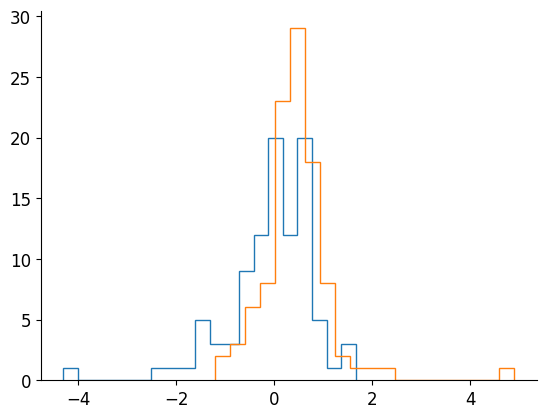

In [18]:
plt.figure()
plt.hist(mm_dec_tpm, histtype='step', bins=20)
plt.hist(mm_inc_tpm, histtype='step', bins=20)

In [19]:
from scipy.stats import mannwhitneyu

In [20]:
mannwhitneyu(mm_dec_tpm, mm_inc_tpm)

MannwhitneyuResult(statistic=3330.0, pvalue=4.6997809651315485e-05)

In [22]:
print(len(mm_dec_tpm))
print(len(mm_inc_tpm))

97
103


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


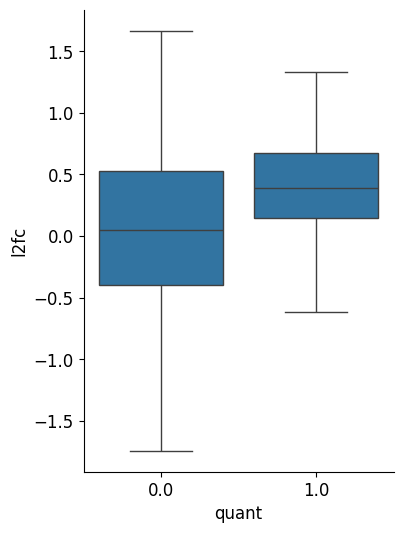

In [23]:
plt.figure(figsize=(4,6))
sns.boxplot(tpms_in_dist, x='quant', y='l2fc', showfliers=False)
plt.savefig(os.path.join(savedir, "changing_mms_txn_crosser.svg"))